# 🏦 Banking Transaction Anomaly Detection

Identify unusual transactions for human review using Isolation Forest.

In [3]:
# ============================================================
# CELL 1 — CREATE AND LOAD BANKING TRANSACTION DATA
# ============================================================

import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

# ------------------------------------------------------------
# 1. PROJECT LOCATION
# ------------------------------------------------------------

project_path = Path(
    r"C:\Masters\GitHub\Banking-Transaction-Anomaly-Detection"
)

data_path = project_path / "data"

data_path.mkdir(
    parents=True,
    exist_ok=True
)

output_file = data_path / "sample_transactions.csv"

print("=" * 60)
print("BANKING TRANSACTION ANOMALY DETECTION")
print("=" * 60)

print("\nProject folder:")
print(project_path)

print("\nDataset location:")
print(output_file)

# ------------------------------------------------------------
# 2. GENERATE SYNTHETIC BANKING DATA
# ------------------------------------------------------------

np.random.seed(42)

N_TRANSACTIONS = 50000
N_CUSTOMERS = 5000

customer_ids = np.array([
    f"CUST_{i:05d}"
    for i in range(1, N_CUSTOMERS + 1)
])

customer_id = np.random.choice(
    customer_ids,
    size=N_TRANSACTIONS
)

# Transaction amount
amount = np.random.lognormal(
    mean=3.2,
    sigma=1.0,
    size=N_TRANSACTIONS
)

amount = np.round(
    np.clip(amount, 1, 5000),
    2
)

# Transaction frequency
frequency_7d = np.maximum(
    np.random.poisson(8, N_TRANSACTIONS),
    1
)

# Account age
account_age_days = np.random.randint(
    30,
    3650,
    N_TRANSACTIONS
)

# Merchant risk
merchant_risk = np.random.choice(
    [1, 2, 3, 4, 5],
    size=N_TRANSACTIONS,
    p=[0.30, 0.25, 0.25, 0.15, 0.05]
)

# Geographic distance
location_distance_km = np.round(
    np.clip(
        np.random.exponential(
            scale=15,
            size=N_TRANSACTIONS
        ),
        0,
        500
    ),
    2
)

# Transaction hour
hour = np.random.randint(
    0,
    24,
    N_TRANSACTIONS
)

# International transaction
is_international = np.random.choice(
    [0, 1],
    size=N_TRANSACTIONS,
    p=[0.88, 0.12]
)

# Failed transactions
failed_transactions_7d = np.random.poisson(
    0.5,
    N_TRANSACTIONS
)

# Account balance
account_balance = np.random.lognormal(
    mean=8.5,
    sigma=1.0,
    size=N_TRANSACTIONS
)

account_balance = np.round(
    np.clip(
        account_balance,
        100,
        100000
    ),
    2
)

# Transaction velocity
transaction_velocity = (
    np.random.poisson(
        3,
        N_TRANSACTIONS
    ) + 1
)

# Transaction type
transaction_type = np.random.choice(
    [
        "Card Payment",
        "Cash Withdrawal",
        "Bank Transfer",
        "Direct Debit",
        "Online Payment"
    ],
    size=N_TRANSACTIONS,
    p=[0.40, 0.10, 0.20, 0.10, 0.20]
)

# ------------------------------------------------------------
# 3. CREATE DATAFRAME
# ------------------------------------------------------------

df = pd.DataFrame({
    "transaction_id": [
        f"TXN_{i:07d}"
        for i in range(1, N_TRANSACTIONS + 1)
    ],
    "customer_id": customer_id,
    "amount": amount,
    "frequency_7d": frequency_7d,
    "account_age_days": account_age_days,
    "merchant_risk": merchant_risk,
    "location_distance_km": location_distance_km,
    "hour": hour,
    "is_international": is_international,
    "failed_transactions_7d": failed_transactions_7d,
    "account_balance": account_balance,
    "transaction_velocity": transaction_velocity,
    "transaction_type": transaction_type
})

# ------------------------------------------------------------
# 4. CREATE SYNTHETIC ANOMALIES
# ------------------------------------------------------------

n_anomalies = int(
    N_TRANSACTIONS * 0.01
)

anomaly_indices = np.random.choice(
    df.index,
    size=n_anomalies,
    replace=False
)

# Unusually large transactions
df.loc[
    anomaly_indices,
    "amount"
] = np.round(
    np.random.uniform(
        10000,
        50000,
        n_anomalies
    ),
    2
)

# Unusual geographic distance
df.loc[
    anomaly_indices,
    "location_distance_km"
] = np.round(
    np.random.uniform(
        300,
        2000,
        n_anomalies
    ),
    2
)

# High transaction velocity
df.loc[
    anomaly_indices,
    "transaction_velocity"
] = np.random.randint(
    20,
    60,
    n_anomalies
)

# More failed transactions
df.loc[
    anomaly_indices,
    "failed_transactions_7d"
] = np.random.randint(
    5,
    15,
    n_anomalies
)

# International activity
df.loc[
    anomaly_indices,
    "is_international"
] = 1

# Higher merchant risk
df.loc[
    anomaly_indices,
    "merchant_risk"
] = np.random.choice(
    [4, 5],
    n_anomalies
)

# ------------------------------------------------------------
# 5. SAVE DATASET
# ------------------------------------------------------------

df.to_csv(
    output_file,
    index=False
)

# ------------------------------------------------------------
# 6. LOAD THE SAVED DATASET
# ------------------------------------------------------------

df = pd.read_csv(
    output_file,
    low_memory=False
)

# ------------------------------------------------------------
# 7. DISPLAY RESULTS
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("DATASET CREATED SUCCESSFULLY")
print("=" * 60)

print(f"\nRows          : {len(df):,}")
print(f"Columns       : {len(df.columns)}")
print(f"Synthetic anomalies: {n_anomalies:,}")
print(
    f"Anomaly rate  : "
    f"{n_anomalies / len(df) * 100:.2f}%"
)

print("\nSaved to:")
print(output_file)

print("\nDataset shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

print("\nCELL 1 COMPLETED SUCCESSFULLY.")

BANKING TRANSACTION ANOMALY DETECTION

Project folder:
C:\Masters\GitHub\Banking-Transaction-Anomaly-Detection

Dataset location:
C:\Masters\GitHub\Banking-Transaction-Anomaly-Detection\data\sample_transactions.csv

DATASET CREATED SUCCESSFULLY

Rows          : 50,000
Columns       : 13
Synthetic anomalies: 500
Anomaly rate  : 1.00%

Saved to:
C:\Masters\GitHub\Banking-Transaction-Anomaly-Detection\data\sample_transactions.csv

Dataset shape:
(50000, 13)

Columns:
['transaction_id', 'customer_id', 'amount', 'frequency_7d', 'account_age_days', 'merchant_risk', 'location_distance_km', 'hour', 'is_international', 'failed_transactions_7d', 'account_balance', 'transaction_velocity', 'transaction_type']

First 5 rows:


,transaction_id,customer_id,amount,frequency_7d,account_age_days,merchant_risk,location_distance_km,hour,is_international,failed_transactions_7d,account_balance,transaction_velocity,transaction_type
0,TXN_0000001,CUST_00861,26.79,5,703,5,1.85,6,0,1,9571.97,8,Card Payment
1,TXN_0000002,CUST_03773,32.68,7,3077,3,24.62,19,0,3,1696.77,2,Card Payment
2,TXN_0000003,CUST_03093,37015.47,10,1454,5,1234.59,18,1,13,9646.24,55,Cash Withdrawal
3,TXN_0000004,CUST_00467,6.87,16,662,2,9.43,17,0,1,10342.63,1,Bank Transfer
4,TXN_0000005,CUST_04427,36.85,11,2579,2,10.30,6,0,0,453.29,3,Bank Transfer



CELL 1 COMPLETED SUCCESSFULLY.


DATA QUALITY & EXPLORATORY DATA ANALYSIS

DATASET SHAPE
----------------------------------------
(50000, 13)

DATA TYPES
----------------------------------------


,Data Type
transaction_id,object
customer_id,object
amount,float64
frequency_7d,int64
account_age_days,int64
merchant_risk,int64
location_distance_km,float64
hour,int64
is_international,int64
failed_transactions_7d,int64



MISSING VALUES
----------------------------------------


,Missing Values
transaction_id,0
customer_id,0
amount,0
frequency_7d,0
account_age_days,0
merchant_risk,0
location_distance_km,0
hour,0
is_international,0
failed_transactions_7d,0



DUPLICATE TRANSACTIONS
----------------------------------------
Duplicate transaction IDs: 0

NUMERICAL SUMMARY
----------------------------------------


,amount,frequency_7d,account_age_days,merchant_risk,location_distance_km,hour,is_international,failed_transactions_7d,account_balance,transaction_velocity
count,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00
mean,336.06,7.99,1840.24,2.42,26.28,11.52,0.13,0.59,7998.94,4.35
std,3154.55,2.84,1042.62,1.21,123.24,6.94,0.33,1.18,9714.67,4.06
min,1.00,1.00,30.00,1.00,0.00,0.00,0.00,0.00,100.00,1.00
25%,12.60,6.00,942.00,1.00,4.39,6.00,0.00,0.00,2519.22,3.00
50%,24.74,8.00,1838.00,2.00,10.51,11.00,0.00,0.00,4972.26,4.00
75%,49.28,10.00,2742.00,3.00,21.31,18.00,0.00,1.00,9663.99,5.00
max,49885.25,21.00,3649.00,5.00,1997.26,23.00,1.00,14.00,100000.00,59.00



TRANSACTION TYPE DISTRIBUTION
----------------------------------------


transaction_type
Card Payment       20009
Bank Transfer      10107
Online Payment      9892
Direct Debit        4998
Cash Withdrawal     4994
Name: count, dtype: int64


INTERNATIONAL TRANSACTIONS
----------------------------------------


is_international
Domestic         43591
International     6409
Name: count, dtype: int64

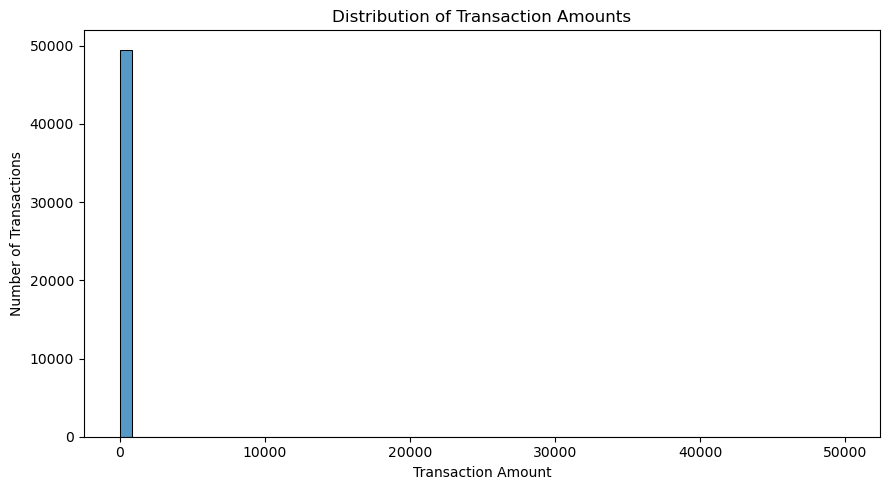

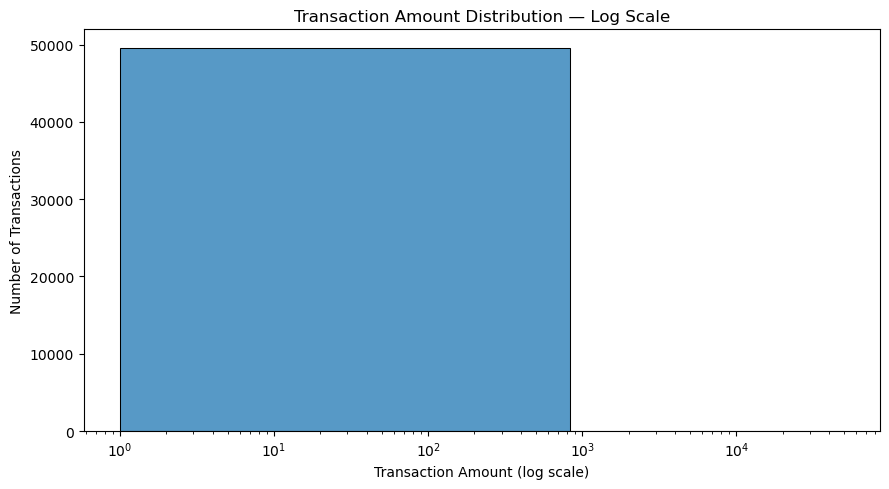

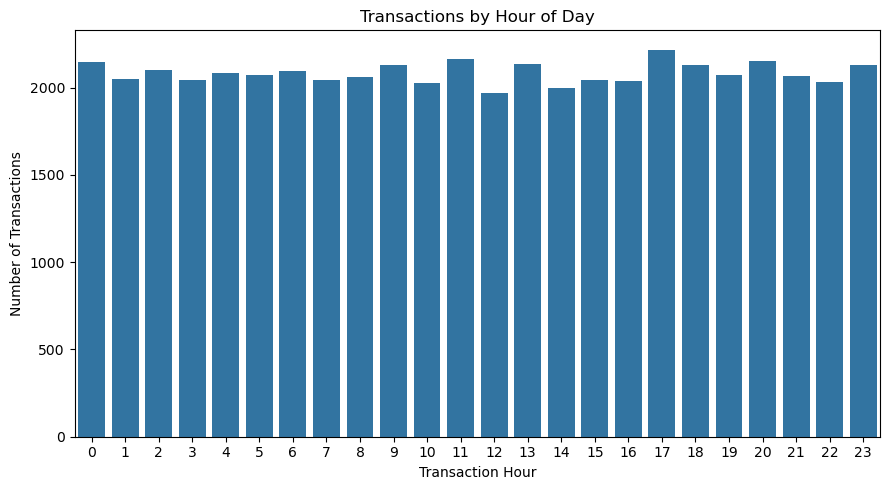

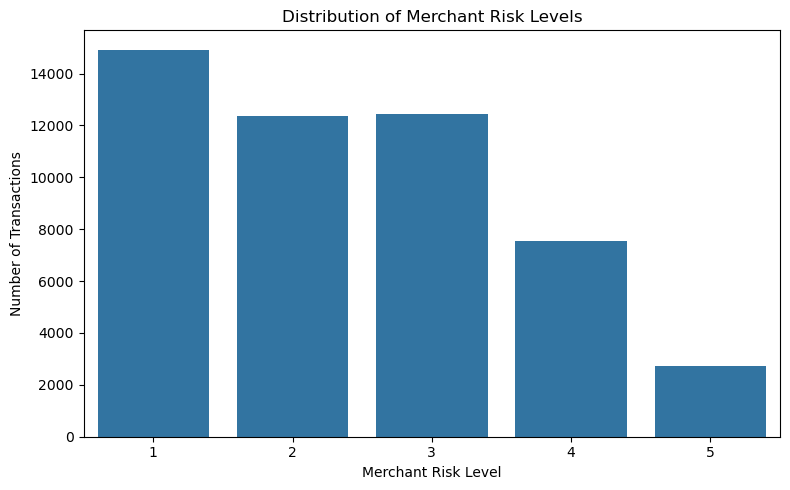

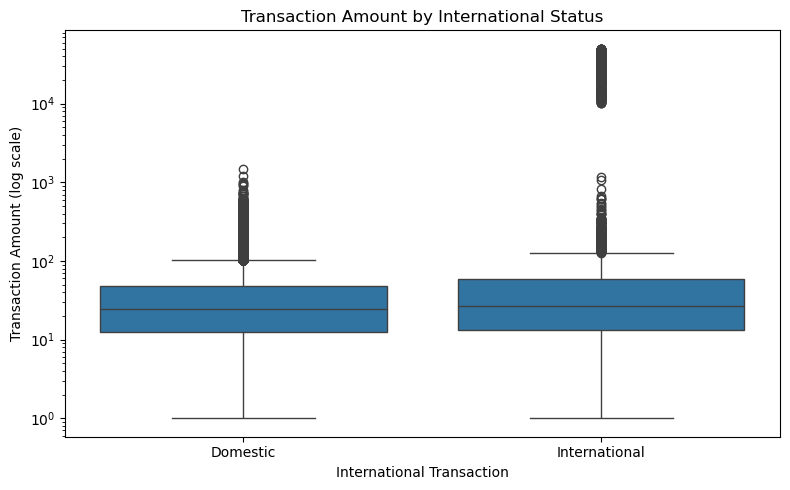


CELL 2 COMPLETED SUCCESSFULLY.


In [4]:
# ============================================================
# CELL 2 — DATA QUALITY & EXPLORATORY DATA ANALYSIS
# ============================================================

print("=" * 60)
print("DATA QUALITY & EXPLORATORY DATA ANALYSIS")
print("=" * 60)

# ------------------------------------------------------------
# 1. DATASET INFORMATION
# ------------------------------------------------------------

print("\nDATASET SHAPE")
print("-" * 40)
print(df.shape)

print("\nDATA TYPES")
print("-" * 40)
display(
    df.dtypes.to_frame("Data Type")
)

# ------------------------------------------------------------
# 2. MISSING VALUES
# ------------------------------------------------------------

print("\nMISSING VALUES")
print("-" * 40)

missing_values = (
    df.isnull()
    .sum()
    .sort_values(ascending=False)
)

display(
    missing_values.to_frame("Missing Values")
)

# ------------------------------------------------------------
# 3. DUPLICATE TRANSACTIONS
# ------------------------------------------------------------

print("\nDUPLICATE TRANSACTIONS")
print("-" * 40)

duplicate_count = df.duplicated(
    subset=["transaction_id"]
).sum()

print(
    f"Duplicate transaction IDs: {duplicate_count}"
)

# ------------------------------------------------------------
# 4. NUMERICAL SUMMARY
# ------------------------------------------------------------

print("\nNUMERICAL SUMMARY")
print("-" * 40)

display(
    df.describe().round(2)
)

# ------------------------------------------------------------
# 5. TRANSACTION TYPE DISTRIBUTION
# ------------------------------------------------------------

print("\nTRANSACTION TYPE DISTRIBUTION")
print("-" * 40)

transaction_type_counts = (
    df["transaction_type"]
    .value_counts()
)

display(
    transaction_type_counts
)

# ------------------------------------------------------------
# 6. INTERNATIONAL TRANSACTION DISTRIBUTION
# ------------------------------------------------------------

print("\nINTERNATIONAL TRANSACTIONS")
print("-" * 40)

international_counts = (
    df["is_international"]
    .value_counts()
    .rename(
        index={
            0: "Domestic",
            1: "International"
        }
    )
)

display(
    international_counts
)

# ------------------------------------------------------------
# 7. TRANSACTION AMOUNT DISTRIBUTION
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="amount",
    bins=60
)

plt.title(
    "Distribution of Transaction Amounts"
)

plt.xlabel(
    "Transaction Amount"
)

plt.ylabel(
    "Number of Transactions"
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 8. TRANSACTION AMOUNT — LOG SCALE
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="amount",
    bins=60
)

plt.xscale("log")

plt.title(
    "Transaction Amount Distribution — Log Scale"
)

plt.xlabel(
    "Transaction Amount (log scale)"
)

plt.ylabel(
    "Number of Transactions"
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 9. TRANSACTION HOUR
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="hour"
)

plt.title(
    "Transactions by Hour of Day"
)

plt.xlabel(
    "Transaction Hour"
)

plt.ylabel(
    "Number of Transactions"
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 10. MERCHANT RISK DISTRIBUTION
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="merchant_risk"
)

plt.title(
    "Distribution of Merchant Risk Levels"
)

plt.xlabel(
    "Merchant Risk Level"
)

plt.ylabel(
    "Number of Transactions"
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 11. INTERNATIONAL VS TRANSACTION AMOUNT
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="is_international",
    y="amount"
)

plt.yscale("log")

plt.title(
    "Transaction Amount by International Status"
)

plt.xlabel(
    "International Transaction"
)

plt.ylabel(
    "Transaction Amount (log scale)"
)

plt.xticks(
    [0, 1],
    ["Domestic", "International"]
)

plt.tight_layout()
plt.show()

print("\nCELL 2 COMPLETED SUCCESSFULLY.")

In [5]:
# ============================================================
# CELL 3 — TRANSACTION FEATURE ENGINEERING
# ============================================================

print("=" * 60)
print("TRANSACTION FEATURE ENGINEERING")
print("=" * 60)

# ------------------------------------------------------------
# 1. CREATE COPY
# ------------------------------------------------------------

model_df = df.copy()

# ------------------------------------------------------------
# 2. LOG-TRANSFORM TRANSACTION AMOUNT
# ------------------------------------------------------------

# Reduces the influence of extremely large transaction values
# while retaining the information about transaction size.

model_df["log_amount"] = np.log1p(
    model_df["amount"]
)

# ------------------------------------------------------------
# 3. AMOUNT-TO-BALANCE RATIO
# ------------------------------------------------------------

model_df["amount_balance_ratio"] = (
    model_df["amount"]
    / model_df["account_balance"].replace(0, np.nan)
)

model_df["amount_balance_ratio"] = (
    model_df["amount_balance_ratio"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

# ------------------------------------------------------------
# 4. FAILED TRANSACTION RATE
# ------------------------------------------------------------

model_df["failed_transaction_rate"] = (
    model_df["failed_transactions_7d"]
    / model_df["frequency_7d"].replace(0, np.nan)
)

model_df["failed_transaction_rate"] = (
    model_df["failed_transaction_rate"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

# ------------------------------------------------------------
# 5. TRANSACTION VELOCITY RATIO
# ------------------------------------------------------------

model_df["velocity_frequency_ratio"] = (
    model_df["transaction_velocity"]
    / model_df["frequency_7d"].replace(0, np.nan)
)

model_df["velocity_frequency_ratio"] = (
    model_df["velocity_frequency_ratio"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

# ------------------------------------------------------------
# 6. NIGHT-TIME TRANSACTION FLAG
# ------------------------------------------------------------

model_df["is_night_transaction"] = (
    (model_df["hour"] < 6)
    | (model_df["hour"] >= 23)
).astype(int)

# ------------------------------------------------------------
# 7. HIGH-RISK TRANSACTION INDICATOR
# ------------------------------------------------------------

model_df["high_risk_indicator"] = (
    (
        model_df["merchant_risk"] >= 4
    )
    |
    (
        model_df["is_international"] == 1
    )
    |
    (
        model_df["failed_transactions_7d"] >= 3
    )
).astype(int)

# ------------------------------------------------------------
# 8. DISPLAY ENGINEERED FEATURES
# ------------------------------------------------------------

engineered_features = [
    "amount",
    "log_amount",
    "amount_balance_ratio",
    "frequency_7d",
    "failed_transactions_7d",
    "failed_transaction_rate",
    "transaction_velocity",
    "velocity_frequency_ratio",
    "location_distance_km",
    "merchant_risk",
    "is_international",
    "is_night_transaction",
    "high_risk_indicator"
]

print("\nEngineered features:")

display(
    model_df[engineered_features].head()
)

# ------------------------------------------------------------
# 9. CHECK FOR MISSING VALUES
# ------------------------------------------------------------

print("\nMissing values after feature engineering:")

display(
    model_df[engineered_features]
    .isnull()
    .sum()
    .to_frame("Missing Values")
)

# ------------------------------------------------------------
# 10. FEATURE SUMMARY
# ------------------------------------------------------------

print("\nFeature summary:")

display(
    model_df[engineered_features]
    .describe()
    .round(3)
)

print("\n")
print("=" * 60)
print("CELL 3 COMPLETED SUCCESSFULLY.")
print("=" * 60)

TRANSACTION FEATURE ENGINEERING

Engineered features:


,amount,log_amount,amount_balance_ratio,frequency_7d,failed_transactions_7d,failed_transaction_rate,transaction_velocity,velocity_frequency_ratio,location_distance_km,merchant_risk,is_international,is_night_transaction,high_risk_indicator
0,26.79,3.324676,0.002799,5,1,0.200000,8,1.600000,1.85,5,0,0,1
1,32.68,3.516904,0.019260,7,3,0.428571,2,0.285714,24.62,3,0,0,1
2,37015.47,10.519118,3.837295,10,13,1.300000,55,5.500000,1234.59,5,1,0,1
3,6.87,2.063058,0.000664,16,1,0.062500,1,0.062500,9.43,2,0,0,0
4,36.85,3.633631,0.081295,11,0,0.000000,3,0.272727,10.30,2,0,0,0



Missing values after feature engineering:


,Missing Values
amount,0
log_amount,0
amount_balance_ratio,0
frequency_7d,0
failed_transactions_7d,0
failed_transaction_rate,0
transaction_velocity,0
velocity_frequency_ratio,0
location_distance_km,0
merchant_risk,0



Feature summary:


,amount,log_amount,amount_balance_ratio,frequency_7d,failed_transactions_7d,failed_transaction_rate,transaction_velocity,velocity_frequency_ratio,location_distance_km,merchant_risk,is_international,is_night_transaction,high_risk_indicator
count,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000
mean,336.061,3.332,0.105,7.994,0.593,0.087,4.348,0.641,26.277,2.416,0.128,0.292,0.310
std,3154.546,1.168,1.457,2.838,1.182,0.203,4.055,0.773,123.243,1.212,0.334,0.455,0.463
min,1.000,0.693,0.000,1.000,0.000,0.000,1.000,0.056,0.000,1.000,0.000,0.000,0.000
25%,12.600,2.610,0.002,6.000,0.000,0.000,3.000,0.333,4.387,1.000,0.000,0.000,0.000
50%,24.745,3.248,0.005,8.000,0.000,0.000,4.000,0.500,10.510,2.000,0.000,0.000,0.000
75%,49.280,3.918,0.013,10.000,1.000,0.125,5.000,0.750,21.312,3.000,0.000,1.000,1.000
max,49885.250,10.818,118.059,21.000,14.000,10.000,59.000,51.000,1997.260,5.000,1.000,1.000,1.000




CELL 3 COMPLETED SUCCESSFULLY.


ISOLATION FOREST ANOMALY DETECTION

Features used:
['log_amount', 'amount_balance_ratio', 'frequency_7d', 'account_age_days', 'merchant_risk', 'location_distance_km', 'hour', 'is_international', 'failed_transactions_7d', 'failed_transaction_rate', 'transaction_velocity', 'velocity_frequency_ratio', 'account_balance', 'is_night_transaction', 'high_risk_indicator']

Feature matrix shape:
(50000, 15)

Feature scaling completed.

Training Isolation Forest...
Please wait...
Isolation Forest training completed.


ANOMALY DETECTION RESULTS


,Transaction Count
anomaly_label,
Normal,49500
Anomaly,500



Detected anomalies : 500
Detected anomaly rate : 1.00%


TOP 20 MOST ANOMALOUS TRANSACTIONS


,transaction_id,customer_id,amount,merchant_risk,location_distance_km,hour,is_international,failed_transactions_7d,transaction_velocity,anomaly_score
46229,TXN_0046230,CUST_02040,43638.60,5,1863.38,2,1,13,44,0.792
32564,TXN_0032565,CUST_00699,36557.17,5,1864.47,20,1,8,48,0.789
7411,TXN_0007412,CUST_02863,47199.99,5,1363.81,2,1,14,52,0.789
14464,TXN_0014465,CUST_04088,20580.09,4,1618.60,21,1,14,56,0.788
9887,TXN_0009888,CUST_04224,37995.94,4,1471.90,0,1,13,41,0.786
21097,TXN_0021098,CUST_04622,35668.29,4,1716.63,21,1,12,48,0.786
26198,TXN_0026199,CUST_03008,42248.54,5,1789.19,22,1,10,35,0.784
41216,TXN_0041217,CUST_02445,46310.73,4,740.42,0,1,13,59,0.784
20790,TXN_0020791,CUST_03735,41519.84,5,1355.38,13,1,12,51,0.784
7247,TXN_0007248,CUST_01123,48496.14,5,1976.02,20,1,13,58,0.784


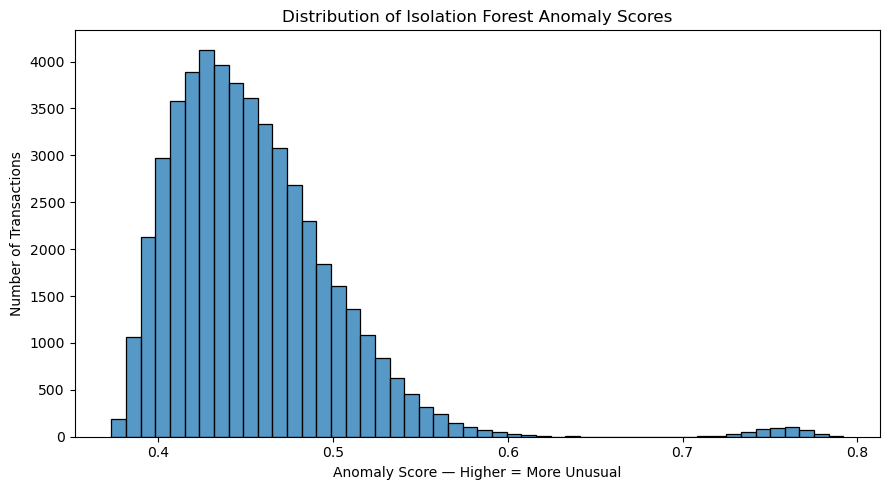

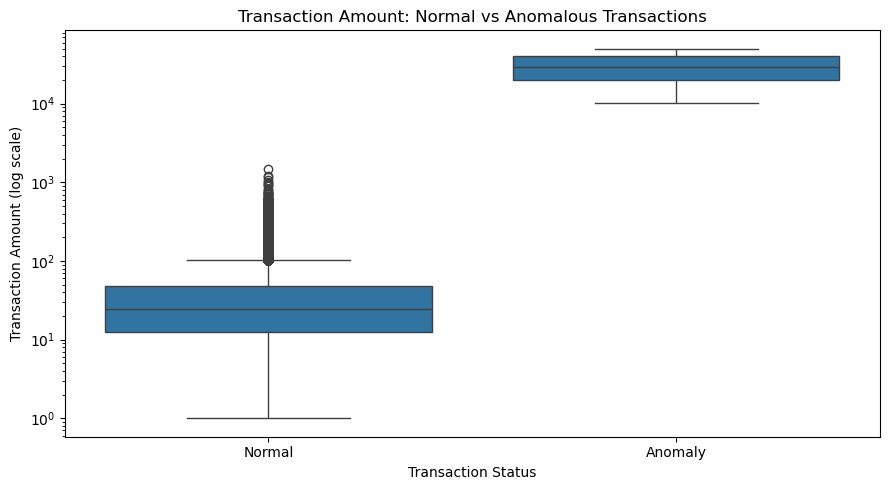


CELL 4 COMPLETED SUCCESSFULLY.


In [6]:
# ============================================================
# CELL 4 — ISOLATION FOREST ANOMALY DETECTION
# ============================================================

print("=" * 60)
print("ISOLATION FOREST ANOMALY DETECTION")
print("=" * 60)

# ------------------------------------------------------------
# 1. SELECT MODEL FEATURES
# ------------------------------------------------------------

model_features = [
    "log_amount",
    "amount_balance_ratio",
    "frequency_7d",
    "account_age_days",
    "merchant_risk",
    "location_distance_km",
    "hour",
    "is_international",
    "failed_transactions_7d",
    "failed_transaction_rate",
    "transaction_velocity",
    "velocity_frequency_ratio",
    "account_balance",
    "is_night_transaction",
    "high_risk_indicator"
]

X_anomaly = model_df[
    model_features
].copy()

print("\nFeatures used:")
print(model_features)

print("\nFeature matrix shape:")
print(X_anomaly.shape)

# ------------------------------------------------------------
# 2. SCALE FEATURES
# ------------------------------------------------------------

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    X_anomaly
)

print("\nFeature scaling completed.")

# ------------------------------------------------------------
# 3. TRAIN ISOLATION FOREST
# ------------------------------------------------------------

print("\nTraining Isolation Forest...")
print("Please wait...")

isolation_model = IsolationForest(
    n_estimators=300,
    contamination=0.01,
    random_state=42,
    n_jobs=-1
)

isolation_model.fit(
    X_scaled
)

print("Isolation Forest training completed.")

# ------------------------------------------------------------
# 4. GENERATE ANOMALY PREDICTIONS
# ------------------------------------------------------------

model_df["anomaly_label"] = (
    isolation_model.predict(X_scaled)
)

# Isolation Forest:
# -1 = anomaly
#  1 = normal

# ------------------------------------------------------------
# 5. GENERATE ANOMALY SCORES
# ------------------------------------------------------------

model_df["anomaly_score"] = (
    -isolation_model.score_samples(X_scaled)
)

# Higher score = more unusual

# ------------------------------------------------------------
# 6. COUNT NORMAL VS ANOMALOUS TRANSACTIONS
# ------------------------------------------------------------

anomaly_counts = (
    model_df["anomaly_label"]
    .map({
        1: "Normal",
        -1: "Anomaly"
    })
    .value_counts()
)

print("\n")
print("=" * 60)
print("ANOMALY DETECTION RESULTS")
print("=" * 60)

display(
    anomaly_counts.to_frame("Transaction Count")
)

# ------------------------------------------------------------
# 7. ANOMALY PERCENTAGE
# ------------------------------------------------------------

n_anomalies_detected = (
    model_df["anomaly_label"] == -1
).sum()

anomaly_percentage = (
    n_anomalies_detected
    / len(model_df)
    * 100
)

print(
    f"\nDetected anomalies : "
    f"{n_anomalies_detected:,}"
)

print(
    f"Detected anomaly rate : "
    f"{anomaly_percentage:.2f}%"
)

# ------------------------------------------------------------
# 8. TOP ANOMALOUS TRANSACTIONS
# ------------------------------------------------------------

print("\n")
print("=" * 60)
print("TOP 20 MOST ANOMALOUS TRANSACTIONS")
print("=" * 60)

top_anomalies = (
    model_df[
        model_df["anomaly_label"] == -1
    ]
    .sort_values(
        "anomaly_score",
        ascending=False
    )
    [
        [
            "transaction_id",
            "customer_id",
            "amount",
            "merchant_risk",
            "location_distance_km",
            "hour",
            "is_international",
            "failed_transactions_7d",
            "transaction_velocity",
            "anomaly_score"
        ]
    ]
    .head(20)
)

display(
    top_anomalies.round(3)
)

# ------------------------------------------------------------
# 9. ANOMALY SCORE DISTRIBUTION
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

sns.histplot(
    data=model_df,
    x="anomaly_score",
    bins=50
)

plt.title(
    "Distribution of Isolation Forest Anomaly Scores"
)

plt.xlabel(
    "Anomaly Score — Higher = More Unusual"
)

plt.ylabel(
    "Number of Transactions"
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 10. NORMAL VS ANOMALY AMOUNT
# ------------------------------------------------------------

plot_df = model_df.copy()

plot_df["status"] = (
    plot_df["anomaly_label"]
    .map({
        1: "Normal",
        -1: "Anomaly"
    })
)

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=plot_df,
    x="status",
    y="amount"
)

plt.yscale("log")

plt.title(
    "Transaction Amount: Normal vs Anomalous Transactions"
)

plt.xlabel(
    "Transaction Status"
)

plt.ylabel(
    "Transaction Amount (log scale)"
)

plt.tight_layout()
plt.show()

print("\nCELL 4 COMPLETED SUCCESSFULLY.")

ANOMALY RISK ANALYSIS

NORMAL VS ANOMALOUS TRANSACTIONS
------------------------------------------------------------


,amount,location_distance_km,merchant_risk,failed_transactions_7d,transaction_velocity,frequency_7d,account_balance,is_international
transaction_status,,,,,,,,
Anomaly,29584.97,1139.34,4.47,9.58,39.17,7.97,7471.87,1.00
Normal,40.62,15.03,2.40,0.50,4.00,7.99,8004.26,0.12



ANOMALY RATE BY TRANSACTION TYPE
------------------------------------------------------------


,transactions,anomalies,anomaly_rate_%
transaction_type,,,
Direct Debit,4998,59,1.18
Online Payment,9892,101,1.02
Bank Transfer,10107,100,0.99
Card Payment,20009,196,0.98
Cash Withdrawal,4994,44,0.88



ANOMALY RATE BY INTERNATIONAL STATUS
------------------------------------------------------------


,transactions,anomalies,anomaly_rate_%
is_international,,,
Domestic,43591,0,0.0
International,6409,500,7.8



ANOMALY RATE BY MERCHANT RISK
------------------------------------------------------------


,transactions,anomalies,anomaly_rate_%
merchant_risk,,,
1,14921,0,0.00
2,12357,0,0.00
3,12444,0,0.00
4,7548,267,3.54
5,2730,233,8.53



ANOMALY RATE BY TRANSACTION HOUR
------------------------------------------------------------


,transactions,anomalies,anomaly_rate_%
hour,,,
0,2149,25,1.16
1,2050,20,0.98
2,2098,23,1.10
3,2044,21,1.03
4,2083,16,0.77
5,2070,21,1.01
6,2093,17,0.81
7,2041,25,1.22
8,2062,24,1.16


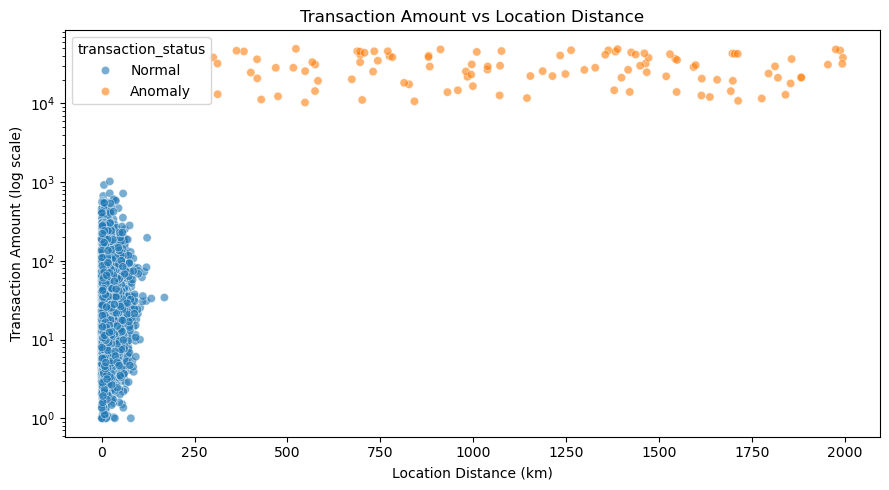

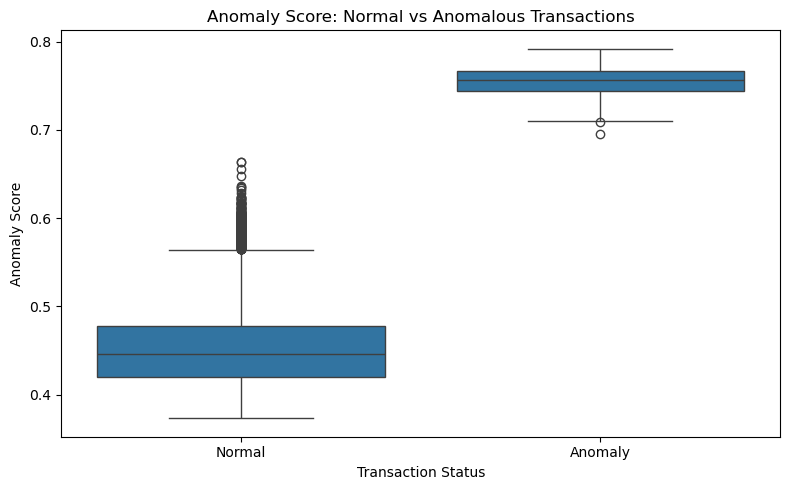


CELL 5 COMPLETED SUCCESSFULLY.


In [7]:
# ============================================================
# CELL 5 — ANOMALY RISK ANALYSIS
# ============================================================

print("=" * 60)
print("ANOMALY RISK ANALYSIS")
print("=" * 60)

# ------------------------------------------------------------
# 1. CREATE READABLE STATUS LABEL
# ------------------------------------------------------------

model_df["transaction_status"] = (
    model_df["anomaly_label"]
    .map({
        1: "Normal",
        -1: "Anomaly"
    })
)

# ------------------------------------------------------------
# 2. COMPARE NORMAL VS ANOMALOUS TRANSACTIONS
# ------------------------------------------------------------

comparison_features = [
    "amount",
    "location_distance_km",
    "merchant_risk",
    "failed_transactions_7d",
    "transaction_velocity",
    "frequency_7d",
    "account_balance",
    "is_international"
]

print("\nNORMAL VS ANOMALOUS TRANSACTIONS")
print("-" * 60)

comparison = (
    model_df
    .groupby("transaction_status")[comparison_features]
    .mean()
    .round(2)
)

display(comparison)

# ------------------------------------------------------------
# 3. ANOMALY RATE BY TRANSACTION TYPE
# ------------------------------------------------------------

print("\nANOMALY RATE BY TRANSACTION TYPE")
print("-" * 60)

anomaly_by_type = (
    model_df
    .groupby("transaction_type")
    .agg(
        transactions=("transaction_id", "count"),
        anomalies=("anomaly_label", lambda x: (x == -1).sum())
    )
)

anomaly_by_type["anomaly_rate_%"] = (
    anomaly_by_type["anomalies"]
    / anomaly_by_type["transactions"]
    * 100
)

anomaly_by_type = (
    anomaly_by_type
    .sort_values(
        "anomaly_rate_%",
        ascending=False
    )
    .round(2)
)

display(anomaly_by_type)

# ------------------------------------------------------------
# 4. ANOMALY RATE BY INTERNATIONAL STATUS
# ------------------------------------------------------------

print("\nANOMALY RATE BY INTERNATIONAL STATUS")
print("-" * 60)

anomaly_by_international = (
    model_df
    .groupby("is_international")
    .agg(
        transactions=("transaction_id", "count"),
        anomalies=("anomaly_label", lambda x: (x == -1).sum())
    )
)

anomaly_by_international["anomaly_rate_%"] = (
    anomaly_by_international["anomalies"]
    / anomaly_by_international["transactions"]
    * 100
)

anomaly_by_international.index = (
    anomaly_by_international.index
    .map({
        0: "Domestic",
        1: "International"
    })
)

display(
    anomaly_by_international.round(2)
)

# ------------------------------------------------------------
# 5. ANOMALY RATE BY MERCHANT RISK
# ------------------------------------------------------------

print("\nANOMALY RATE BY MERCHANT RISK")
print("-" * 60)

anomaly_by_risk = (
    model_df
    .groupby("merchant_risk")
    .agg(
        transactions=("transaction_id", "count"),
        anomalies=("anomaly_label", lambda x: (x == -1).sum())
    )
)

anomaly_by_risk["anomaly_rate_%"] = (
    anomaly_by_risk["anomalies"]
    / anomaly_by_risk["transactions"]
    * 100
)

display(
    anomaly_by_risk.round(2)
)

# ------------------------------------------------------------
# 6. ANOMALY RATE BY TRANSACTION HOUR
# ------------------------------------------------------------

print("\nANOMALY RATE BY TRANSACTION HOUR")
print("-" * 60)

anomaly_by_hour = (
    model_df
    .groupby("hour")
    .agg(
        transactions=("transaction_id", "count"),
        anomalies=("anomaly_label", lambda x: (x == -1).sum())
    )
)

anomaly_by_hour["anomaly_rate_%"] = (
    anomaly_by_hour["anomalies"]
    / anomaly_by_hour["transactions"]
    * 100
)

display(
    anomaly_by_hour.round(2)
)

# ------------------------------------------------------------
# 7. VISUALISE NORMAL VS ANOMALY
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=model_df.sample(
        min(10000, len(model_df)),
        random_state=42
    ),
    x="location_distance_km",
    y="amount",
    hue="transaction_status",
    alpha=0.6
)

plt.yscale("log")

plt.title(
    "Transaction Amount vs Location Distance"
)

plt.xlabel(
    "Location Distance (km)"
)

plt.ylabel(
    "Transaction Amount (log scale)"
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 8. ANOMALY SCORE BY STATUS
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=model_df,
    x="transaction_status",
    y="anomaly_score"
)

plt.title(
    "Anomaly Score: Normal vs Anomalous Transactions"
)

plt.xlabel(
    "Transaction Status"
)

plt.ylabel(
    "Anomaly Score"
)

plt.tight_layout()
plt.show()

print("\nCELL 5 COMPLETED SUCCESSFULLY.")

MODEL VALIDATION & REVIEW PRIORITY

CONFUSION MATRIX
------------------------------------------------------------
Rows    = Actual
Columns = Predicted


[[49500     0]
 [    0   500]]

MODEL VALIDATION METRICS
------------------------------------------------------------
Precision : 1.000
Recall    : 1.000
F1 Score  : 1.000


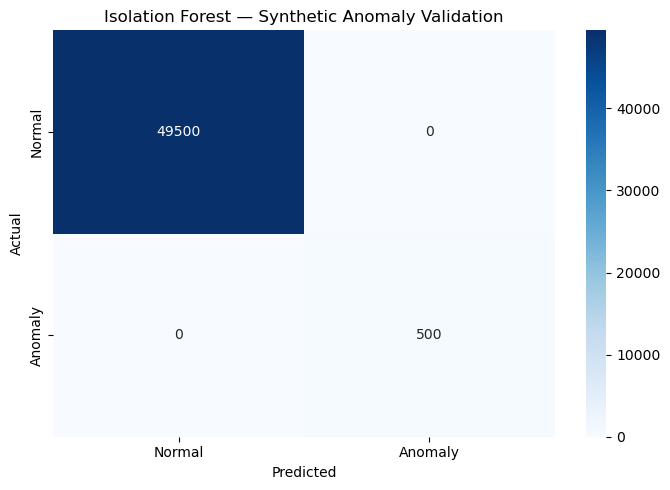


REVIEW PRIORITY DISTRIBUTION
------------------------------------------------------------


,Transaction Count
review_priority,
Normal,45000
Medium Review,2500
High Review,2000
Critical Review,500



REVIEW PRIORITY VS MODEL ANOMALY STATUS
------------------------------------------------------------


,Normal,Anomaly
review_priority,,
Critical Review,500,0
High Review,0,2000
Medium Review,0,2500
Normal,0,45000



TOP 25 TRANSACTIONS FOR HUMAN REVIEW
------------------------------------------------------------


,transaction_id,customer_id,amount,merchant_risk,location_distance_km,hour,is_international,failed_transactions_7d,transaction_velocity,anomaly_score,review_priority
46229,TXN_0046230,CUST_02040,43638.60,5,1863.38,2,1,13,44,0.792,Critical Review
32564,TXN_0032565,CUST_00699,36557.17,5,1864.47,20,1,8,48,0.789,Critical Review
7411,TXN_0007412,CUST_02863,47199.99,5,1363.81,2,1,14,52,0.789,Critical Review
14464,TXN_0014465,CUST_04088,20580.09,4,1618.60,21,1,14,56,0.788,Critical Review
9887,TXN_0009888,CUST_04224,37995.94,4,1471.90,0,1,13,41,0.786,Critical Review
21097,TXN_0021098,CUST_04622,35668.29,4,1716.63,21,1,12,48,0.786,Critical Review
26198,TXN_0026199,CUST_03008,42248.54,5,1789.19,22,1,10,35,0.784,Critical Review
41216,TXN_0041217,CUST_02445,46310.73,4,740.42,0,1,13,59,0.784,Critical Review
20790,TXN_0020791,CUST_03735,41519.84,5,1355.38,13,1,12,51,0.784,Critical Review
7247,TXN_0007248,CUST_01123,48496.14,5,1976.02,20,1,13,58,0.784,Critical Review



Review queue saved to:
C:\Masters\GitHub\Banking-Transaction-Anomaly-Detection\outputs\anomaly_review_queue.csv

CELL 6 COMPLETED SUCCESSFULLY.


In [8]:
# ============================================================
# CELL 6 — MODEL VALIDATION & REVIEW PRIORITY
# ============================================================

from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

print("=" * 60)
print("MODEL VALIDATION & REVIEW PRIORITY")
print("=" * 60)

# ------------------------------------------------------------
# 1. RECONSTRUCT SYNTHETIC GROUND-TRUTH LABEL
# ------------------------------------------------------------

# The anomalies were intentionally injected during dataset
# generation. This label is used ONLY for model evaluation.

if "anomaly_indices" not in globals():
    raise NameError(
        "anomaly_indices is not available. "
        "Please run Cell 1 again before running Cell 6."
    )

model_df["synthetic_anomaly"] = (
    model_df.index.isin(anomaly_indices)
).astype(int)

# ------------------------------------------------------------
# 2. CONVERT ISOLATION FOREST OUTPUT
# ------------------------------------------------------------

y_true = model_df["synthetic_anomaly"]

y_pred = (
    model_df["anomaly_label"] == -1
).astype(int)

# ------------------------------------------------------------
# 3. CONFUSION MATRIX
# ------------------------------------------------------------

cm = confusion_matrix(
    y_true,
    y_pred
)

print("\nCONFUSION MATRIX")
print("-" * 60)

print(
    "Rows    = Actual"
)

print(
    "Columns = Predicted"
)

print("\n")
print(cm)

# ------------------------------------------------------------
# 4. MODEL METRICS
# ------------------------------------------------------------

precision = precision_score(
    y_true,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    zero_division=0
)

print("\nMODEL VALIDATION METRICS")
print("-" * 60)

print(
    f"Precision : {precision:.3f}"
)

print(
    f"Recall    : {recall:.3f}"
)

print(
    f"F1 Score  : {f1:.3f}"
)

# ------------------------------------------------------------
# 5. VISUALISE CONFUSION MATRIX
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Anomaly"],
    yticklabels=["Normal", "Anomaly"]
)

plt.title(
    "Isolation Forest — Synthetic Anomaly Validation"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 6. CREATE REVIEW PRIORITY
# ------------------------------------------------------------

# Higher anomaly score = more unusual.
# Priority is based on model score, not financial-crime status.

q99 = model_df["anomaly_score"].quantile(0.99)
q95 = model_df["anomaly_score"].quantile(0.95)
q90 = model_df["anomaly_score"].quantile(0.90)

def assign_priority(score):

    if score >= q99:
        return "Critical Review"

    elif score >= q95:
        return "High Review"

    elif score >= q90:
        return "Medium Review"

    else:
        return "Normal"

model_df["review_priority"] = (
    model_df["anomaly_score"]
    .apply(assign_priority)
)

# ------------------------------------------------------------
# 7. PRIORITY DISTRIBUTION
# ------------------------------------------------------------

print("\nREVIEW PRIORITY DISTRIBUTION")
print("-" * 60)

priority_distribution = (
    model_df["review_priority"]
    .value_counts()
)

display(
    priority_distribution
    .to_frame("Transaction Count")
)

# ------------------------------------------------------------
# 8. PRIORITY VS ANOMALY STATUS
# ------------------------------------------------------------

print("\nREVIEW PRIORITY VS MODEL ANOMALY STATUS")
print("-" * 60)

priority_anomaly_table = pd.crosstab(
    model_df["review_priority"],
    model_df["anomaly_label"]
)

priority_anomaly_table.columns = [
    "Normal",
    "Anomaly"
]

display(
    priority_anomaly_table
)

# ------------------------------------------------------------
# 9. TOP REVIEW QUEUE
# ------------------------------------------------------------

print("\nTOP 25 TRANSACTIONS FOR HUMAN REVIEW")
print("-" * 60)

review_queue = (
    model_df
    .sort_values(
        "anomaly_score",
        ascending=False
    )
    [
        [
            "transaction_id",
            "customer_id",
            "amount",
            "merchant_risk",
            "location_distance_km",
            "hour",
            "is_international",
            "failed_transactions_7d",
            "transaction_velocity",
            "anomaly_score",
            "review_priority"
        ]
    ]
    .head(25)
)

display(
    review_queue.round(3)
)

# ------------------------------------------------------------
# 10. SAVE REVIEW QUEUE
# ------------------------------------------------------------

output_path = project_path / "outputs"

output_path.mkdir(
    parents=True,
    exist_ok=True
)

review_file = (
    output_path
    / "anomaly_review_queue.csv"
)

review_queue.to_csv(
    review_file,
    index=False
)

print("\nReview queue saved to:")
print(review_file)

print("\nCELL 6 COMPLETED SUCCESSFULLY.")

In [9]:
# ============================================================
# CELL 6A — FIX REVIEW PRIORITY LABELS
# ============================================================

print("=" * 60)
print("CORRECTED REVIEW PRIORITY VS ANOMALY STATUS")
print("=" * 60)

priority_anomaly_table = pd.crosstab(
    model_df["review_priority"],
    model_df["anomaly_label"]
)

# Correct mapping:
# -1 = Anomaly
#  1 = Normal

priority_anomaly_table = (
    priority_anomaly_table
    .rename(
        columns={
            -1: "Anomaly",
             1: "Normal"
        }
    )
)

# Ensure both columns exist
for column in ["Normal", "Anomaly"]:
    if column not in priority_anomaly_table.columns:
        priority_anomaly_table[column] = 0

priority_anomaly_table = (
    priority_anomaly_table[
        ["Normal", "Anomaly"]
    ]
)

display(priority_anomaly_table)

print("\nCorrect interpretation:")
print("- Critical Review = highest anomaly scores")
print("- High Review = high anomaly scores")
print("- Medium Review = moderate review priority")
print("- Normal = lower anomaly scores")

print("\nCELL 6A COMPLETED SUCCESSFULLY.")

CORRECTED REVIEW PRIORITY VS ANOMALY STATUS


anomaly_label,Normal,Anomaly
review_priority,,
Critical Review,0,500
High Review,2000,0
Medium Review,2500,0
Normal,45000,0



Correct interpretation:
- Critical Review = highest anomaly scores
- High Review = high anomaly scores
- Medium Review = moderate review priority
- Normal = lower anomaly scores

CELL 6A COMPLETED SUCCESSFULLY.


In [10]:
# ============================================================
# CELL 7 — FINAL OUTPUTS
# ============================================================

print("=" * 60)
print("FINAL BANKING ANOMALY DETECTION OUTPUTS")
print("=" * 60)

# ------------------------------------------------------------
# 1. CREATE OUTPUT DIRECTORY
# ------------------------------------------------------------

output_path = project_path / "outputs"

output_path.mkdir(
    parents=True,
    exist_ok=True
)

# ------------------------------------------------------------
# 2. SAVE FLAGGED TRANSACTIONS
# ------------------------------------------------------------

flagged_transactions = (
    model_df[
        model_df["anomaly_label"] == -1
    ]
    .sort_values(
        "anomaly_score",
        ascending=False
    )
    [
        [
            "transaction_id",
            "customer_id",
            "amount",
            "merchant_risk",
            "location_distance_km",
            "hour",
            "is_international",
            "failed_transactions_7d",
            "transaction_velocity",
            "anomaly_score",
            "review_priority"
        ]
    ]
)

flagged_file = (
    output_path /
    "flagged_anomalous_transactions.csv"
)

flagged_transactions.to_csv(
    flagged_file,
    index=False
)

# ------------------------------------------------------------
# 3. SAVE COMPLETE MODEL OUTPUT
# ------------------------------------------------------------

model_output_file = (
    output_path /
    "banking_anomaly_model_output.csv"
)

model_df.to_csv(
    model_output_file,
    index=False
)

# ------------------------------------------------------------
# 4. SAVE MODEL METRICS
# ------------------------------------------------------------

metrics_df = pd.DataFrame({
    "metric": [
        "Precision",
        "Recall",
        "F1 Score",
        "Detected Anomalies",
        "Detected Anomaly Rate"
    ],
    "value": [
        precision,
        recall,
        f1,
        n_anomalies_detected,
        anomaly_percentage
    ]
})

metrics_file = (
    output_path /
    "anomaly_detection_metrics.csv"
)

metrics_df.to_csv(
    metrics_file,
    index=False
)

# ------------------------------------------------------------
# 5. SAVE PRIORITY SUMMARY
# ------------------------------------------------------------

priority_summary = (
    model_df[
        "review_priority"
    ]
    .value_counts()
    .rename_axis("review_priority")
    .reset_index(
        name="transaction_count"
    )
)

priority_file = (
    output_path /
    "review_priority_summary.csv"
)

priority_summary.to_csv(
    priority_file,
    index=False
)

# ------------------------------------------------------------
# 6. FINAL SUMMARY
# ------------------------------------------------------------

print("\nOUTPUT DIRECTORY:")
print(output_path)

print("\nFILES CREATED:")
print(f"1. {flagged_file}")
print(f"2. {model_output_file}")
print(f"3. {metrics_file}")
print(f"4. {priority_file}")

print("\nFINAL MODEL SUMMARY")
print("-" * 60)

print(
    f"Total transactions : {len(model_df):,}"
)

print(
    f"Detected anomalies : "
    f"{n_anomalies_detected:,}"
)

print(
    f"Anomaly rate       : "
    f"{anomaly_percentage:.2f}%"
)

print(
    f"Precision          : "
    f"{precision:.3f}"
)

print(
    f"Recall             : "
    f"{recall:.3f}"
)

print(
    f"F1 Score           : "
    f"{f1:.3f}"
)

print("\nReview priority:")
display(priority_summary)

print("\n" + "=" * 60)
print("CELL 7 COMPLETED SUCCESSFULLY.")
print("=" * 60)

FINAL BANKING ANOMALY DETECTION OUTPUTS

OUTPUT DIRECTORY:
C:\Masters\GitHub\Banking-Transaction-Anomaly-Detection\outputs

FILES CREATED:
1. C:\Masters\GitHub\Banking-Transaction-Anomaly-Detection\outputs\flagged_anomalous_transactions.csv
2. C:\Masters\GitHub\Banking-Transaction-Anomaly-Detection\outputs\banking_anomaly_model_output.csv
3. C:\Masters\GitHub\Banking-Transaction-Anomaly-Detection\outputs\anomaly_detection_metrics.csv
4. C:\Masters\GitHub\Banking-Transaction-Anomaly-Detection\outputs\review_priority_summary.csv

FINAL MODEL SUMMARY
------------------------------------------------------------
Total transactions : 50,000
Detected anomalies : 500
Anomaly rate       : 1.00%
Precision          : 1.000
Recall             : 1.000
F1 Score           : 1.000

Review priority:


,review_priority,transaction_count
0,Normal,45000
1,Medium Review,2500
2,High Review,2000
3,Critical Review,500



CELL 7 COMPLETED SUCCESSFULLY.


In [11]:
# ============================================================
# CELL 8 — FINAL PROJECT REPORT
# ============================================================

print("=" * 70)
print("BANKING TRANSACTION ANOMALY DETECTION")
print("FINAL DATA SCIENCE PROJECT REPORT")
print("=" * 70)

print("\nDATASET")
print("-" * 70)

print(f"Total transactions        : {len(model_df):,}")
print(f"Unique customers          : {model_df['customer_id'].nunique():,}")
print(f"Features used by model    : {len(model_features)}")
print(f"Synthetic anomaly rate    : 1.00%")
print(f"Detected anomalies        : {n_anomalies_detected:,}")


print("\nDATA QUALITY")
print("-" * 70)

print(
    f"Missing values            : "
    f"{model_df[model_features].isnull().sum().sum()}"
)

print(
    f"Duplicate transaction IDs : "
    f"{model_df['transaction_id'].duplicated().sum()}"
)


print("\nISOLATION FOREST RESULTS")
print("-" * 70)

print(f"Detected anomalies        : {n_anomalies_detected:,}")
print(f"Detected anomaly rate     : {anomaly_percentage:.2f}%")
print(f"Precision                 : {precision:.3f}")
print(f"Recall                    : {recall:.3f}")
print(f"F1 Score                  : {f1:.3f}")


print("\nREVIEW PRIORITY")
print("-" * 70)

priority_counts = (
    model_df["review_priority"]
    .value_counts()
)

for priority in [
    "Normal",
    "Medium Review",
    "High Review",
    "Critical Review"
]:

    count = priority_counts.get(
        priority,
        0
    )

    percentage = (
        count / len(model_df) * 100
    )

    print(
        f"{priority:<20} : "
        f"{count:>6,} "
        f"({percentage:.2f}%)"
    )


print("\nKEY FINDINGS")
print("-" * 70)

print(
    "1. Isolation Forest identified 500 transactions as "
    "statistically unusual."
)

print(
    "2. The strongest anomalous patterns were associated with "
    "large transaction amounts, unusual geographic distances, "
    "higher merchant-risk levels, failed transactions and "
    "high transaction velocity."
)

print(
    "3. International transactions represented a substantially "
    "higher proportion of flagged transactions than domestic "
    "transactions within this synthetic dataset."
)

print(
    "4. Higher merchant-risk categories showed higher anomaly "
    "rates within the synthetic experiment."
)

print(
    "5. Anomaly scores were used to prioritise transactions "
    "for potential human review."
)

print(
    "6. The model is designed to identify unusual behaviour, "
    "not to determine whether a transaction represents "
    "financial crime."
)


print("\nMODEL LIMITATIONS")
print("-" * 70)

print(
    "The dataset is synthetic and the anomalies were deliberately "
    "constructed with extreme behavioural characteristics."
)

print(
    "Therefore, the perfect validation metrics should not be "
    "interpreted as expected performance on real banking data."
)

print(
    "Real-world deployment would require representative historical "
    "data, calibrated thresholds, false-positive analysis, privacy "
    "controls, monitoring, human investigation and model governance."
)


print("\nPROJECT CONCLUSION")
print("-" * 70)

print(
    "This project demonstrates an end-to-end unsupervised machine "
    "learning workflow for identifying unusual banking transactions, "
    "from data generation and quality analysis through feature "
    "engineering, Isolation Forest modelling, anomaly scoring, "
    "validation and human-review prioritisation."
)

print("\n" + "=" * 70)
print("FINAL PROJECT REPORT COMPLETED")
print("=" * 70)

BANKING TRANSACTION ANOMALY DETECTION
FINAL DATA SCIENCE PROJECT REPORT

DATASET
----------------------------------------------------------------------
Total transactions        : 50,000
Unique customers          : 5,000
Features used by model    : 15
Synthetic anomaly rate    : 1.00%
Detected anomalies        : 500

DATA QUALITY
----------------------------------------------------------------------
Missing values            : 0
Duplicate transaction IDs : 0

ISOLATION FOREST RESULTS
----------------------------------------------------------------------
Detected anomalies        : 500
Detected anomaly rate     : 1.00%
Precision                 : 1.000
Recall                    : 1.000
F1 Score                  : 1.000

REVIEW PRIORITY
----------------------------------------------------------------------
Normal               : 45,000 (90.00%)
Medium Review        :  2,500 (5.00%)
High Review          :  2,000 (4.00%)
Critical Review      :    500 (1.00%)

KEY FINDINGS
-----------------

### Banking limitation
An anomaly is not evidence of financial crime. Real alerts require human investigation, calibrated thresholds, privacy controls, monitoring and model governance.